In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt
import cmocean
from scipy.ndimage import distance_transform_edt as edt

In [4]:
from regions import ROSS_BOUNDS

x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

## Load Bedmap3 data

In [ ]:
# TODO: define local path to bedmap3 file
path_to_bedmap3 = "bedmap3/bedmap3.nc"
bm = xr.open_dataset(path_to_bedmap3)

## Subset

In [6]:
bm_ross = bm.sel(
    x = slice(x_min, x_max), 
    y = slice(y_max, y_min))

bm_ross

<xarray.Dataset> Size: 112MB
Dimensions:                 (x: 2000, y: 2000)
Coordinates:
  * x                       (x) float32 8kB -5.998e+05 -5.992e+05 ... 3.998e+05
  * y                       (y) float32 8kB -4.002e+05 -4.008e+05 ... -1.4e+06
Data variables:
    surface_topography      (y, x) float32 16MB ...
    bed_uncertainty         (y, x) float32 16MB ...
    bed_topography          (y, x) float32 16MB ...
    mask                    (y, x) float32 16MB ...
    ice_thickness           (y, x) float32 16MB ...
    thickness_survey_count  (y, x) float32 16MB ...
    thickness_uncertainty   (y, x) float32 16MB ...
    mapping                 <U19 76B ...
Attributes: (12/26)
    crs:                    EPSG:3031
    title:                  BEDMAP3 - Ice thickness, bed and surface elevatio...
    summary:                We present here Bedmap3, the latest suite of grid...
    keywords:               Antarctica,BEDMAP,Elevation,Ice thickness
    Conventions:            ACDD-1.3, CF-1.8
    citation:               Pritchard, H., Fretwell, P., Fremand, A., Bodart,...
    ...                     ...
    time_coverage_end:      2024-11-01
    geospatial_lon_min:     -180
    geospatial_lon_max:     180
    geospatial_lat_min:     -90
    geospatial_lat_max:     -60
    geospatial_bounds_crs:  EPSG:4326

## Remove small area that is not quite ice shelf

In [7]:
rm_x_min, rm_x_max = -600_000, -500_000
rm_y_min, rm_y_max = -1_400_000, -1_200_000

# Outside box (anti-select)
mask = ((bm_ross.x < rm_x_min) | (bm_ross.x > rm_x_max) | 
        (bm_ross.y < rm_y_min) | (bm_ross.y > rm_y_max))

bm_ross = bm_ross.where(mask, drop = True)

# Inspect mask

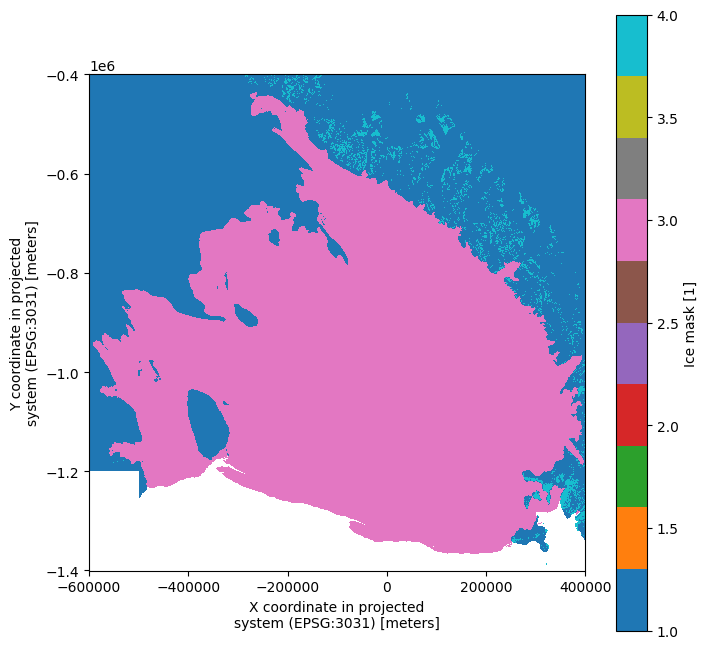

In [8]:
fig, ax = plt.subplots(figsize = (8, 8))

# Plot using pcolormesh
bm_ross.mask.plot.pcolormesh(ax = ax, cmap = "tab10", add_colorbar = True)

ax.set_aspect("equal")
plt.show()

# Crop ice thickness to mask

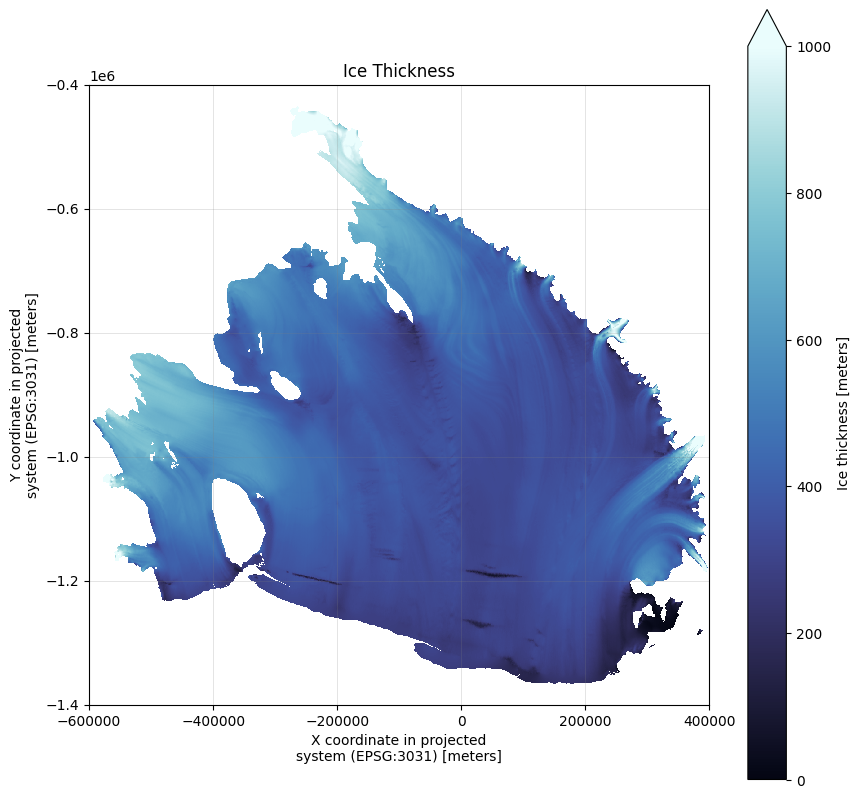

In [9]:
fig, ax = plt.subplots(figsize = (10, 10))

# Plot only the subset where mask == 3
bm_ross.ice_thickness.where(bm_ross.mask == 3).plot.pcolormesh(
    ax = ax, cmap = cmocean.cm.ice, vmin = 0, vmax = 1000)

ax.set_title("Ice Thickness")
ax.grid(True, which = "both", color = "grey", alpha = 0.3, linewidth = 0.5)
ax.set_aspect("equal")
# plt.savefig("figures/ice_thickness_bedmap3.png", dpi = 300, bbox_inches = "tight")
plt.show()

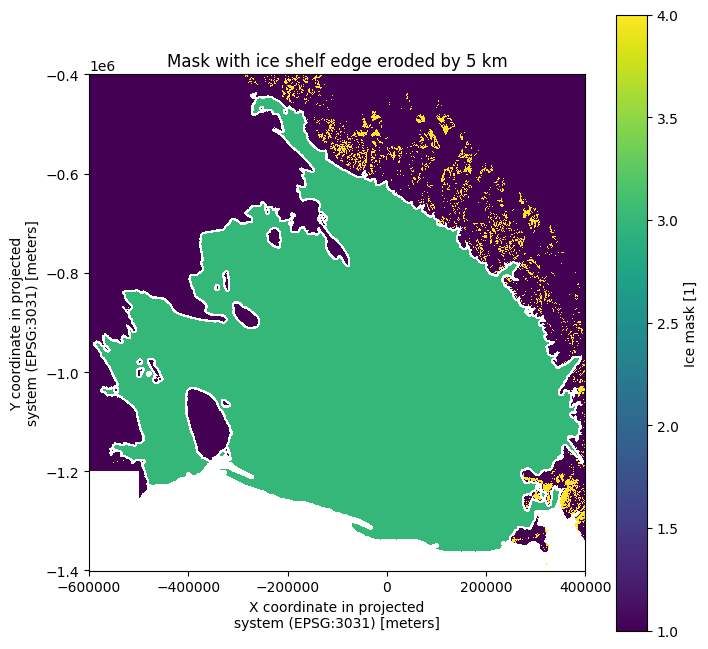

In [10]:
from scipy.ndimage import distance_transform_edt as edt

# values: 1, 3, 4, nan
mask = bm_ross.mask
is3 = (mask == 3)

# Get pixel sizes from coordinates (assumes regular grid, in meters)
dx = float(abs(bm_ross[x := is3.dims[1]].diff(x).median()))
dy = float(abs(bm_ross[y := is3.dims[0]].diff(y).median()))
# If your dims are ('y','x'), this picks them correctly

# Distance (meters) from each class-3 pixel to the nearest non-3 pixel
# Note: edt treats non-zero as foreground; we use is3 as foreground.
dist_m = edt(is3.fillna(False).values, sampling = (dy, dx))

# Keep only the "core" that is at least 5000 m from the edge
core3 = xr.DataArray(dist_m, coords = is3.coords, dims = is3.dims) >= 5000.0

# Build a new mask where edge-near 3’s are removed (set to NaN)
tighter_ice_shelf_mask = mask.where(~is3, xr.where(core3, 3, np.nan))

# Example plot
fig, ax = plt.subplots(figsize = (8, 8))
tighter_ice_shelf_mask.plot.pcolormesh(ax = ax, cmap = "viridis")
ax.set_aspect("equal")
ax.set_title("Mask with ice shelf edge eroded by 5 km")
plt.show()

In [11]:
mask_bool = (tighter_ice_shelf_mask == 3)
# Count number of True values
mask_bool.sum().item()

tighter_ice_shelf_mask = mask_bool.astype("int8")

In [12]:
tighter_ice_shelf_mask

<xarray.DataArray 'mask' (y: 2000, x: 2000)> Size: 4MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)
Coordinates:
  * x        (x) float32 8kB -5.998e+05 -5.992e+05 ... 3.992e+05 3.998e+05
  * y        (y) float32 8kB -4.002e+05 -4.008e+05 ... -1.399e+06 -1.4e+06

In [13]:
tighter_ice_shelf_mask.to_netcdf("data/target_grid_mask.nc")

In [17]:
# Make it boolean: True where ice shelf (class 3)
tighter_ice_shelf_mask = (tighter_ice_shelf_mask == 3)
tighter_ice_shelf_mask.to_netcdf("data/target_grid_mask.nc")

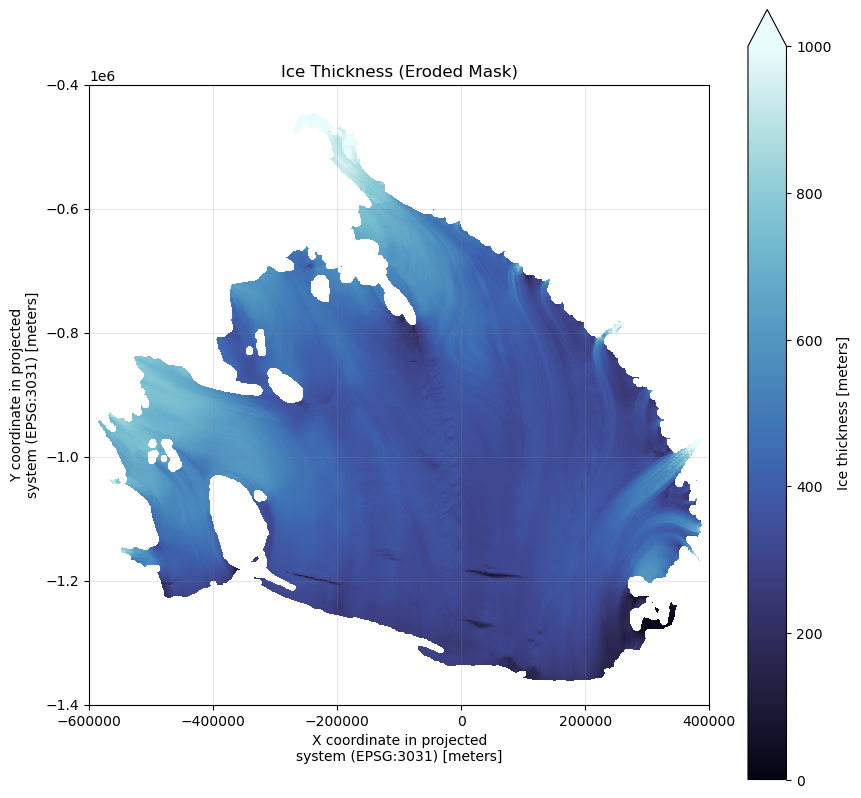

In [49]:
fig, ax = plt.subplots(figsize = (10, 10))

# Use eroded mask instead of the raw one
bm_ross.ice_thickness.where(tighter_ice_shelf_mask == 3).plot.pcolormesh(
    ax = ax, cmap = cmocean.cm.ice, vmin = 0, vmax = 1000
)

ax.set_title("Ice Thickness (Eroded Mask)")
ax.grid(True, which = "both", color = "grey", alpha = 0.3, linewidth = 0.5)
ax.set_aspect("equal")

plt.savefig("figures/ice_thickness_bedmap3_eroded_5km.png", dpi = 300, bbox_inches = "tight")
plt.show()

# Export grid

In [59]:
tight_mask = (tighter_ice_shelf_mask.values == 3)

XX, YY = np.meshgrid(bm_ross.x.values, bm_ross.y.values, indexing = "xy")

XX_tensor = torch.from_numpy(XX[tight_mask])
YY_tensor = torch.from_numpy(YY[tight_mask])

# Make grid in APS coordinates
bedmap_grid = torch.cat(
    (XX_tensor.unsqueeze(0),
     YY_tensor.unsqueeze(0)), dim = 0
)

print("Full grid shape:")
print(bedmap_grid.shape)
# Save grid
torch.save(bedmap_grid, "data/bedmap_500m_grid_ross_long.pt")

# Make grid in norm coordinates [0, 1]
XX_norm = (XX_tensor - x_min) / (x_max - x_min)
YY_norm = (YY_tensor - y_min) / (y_max - y_min)

bedmap_grid_norm = torch.cat((
    XX_norm.unsqueeze(0),
    YY_norm.unsqueeze(0)), dim = 0)

print()
print("Normalized grid shape:")
print(bedmap_grid_norm.shape)

# Save grid
torch.save(bedmap_grid_norm, "data/bedmap_500m_grid_ross_norm_long.pt")

Full grid shape:
torch.Size([2, 1809659])

Normalized grid shape:
torch.Size([2, 1809659])


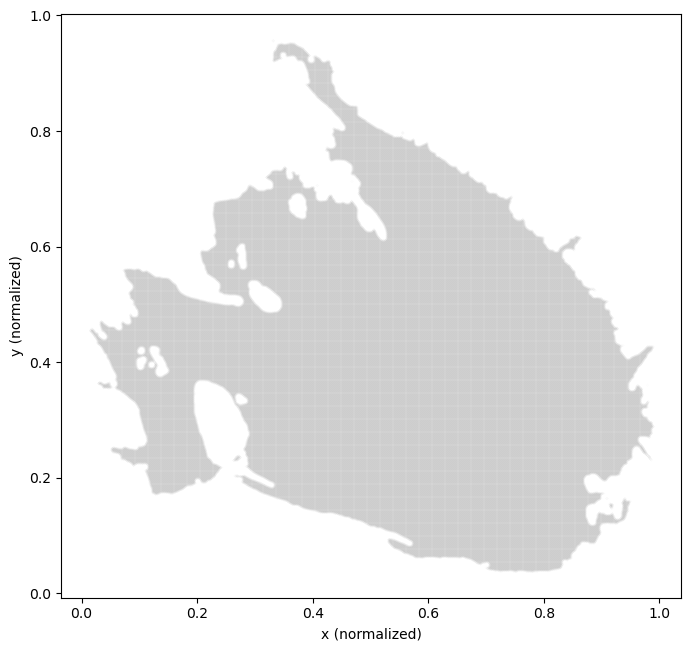

In [57]:
# Scatter plot
plt.figure(figsize = (8, 8))
plt.scatter(
    bedmap_grid_norm[0], 
    bedmap_grid_norm[1],
    s = 0.00001
)
plt.xlabel("x (normalized)")
plt.ylabel("y (normalized)")
plt.gca().set_aspect("equal", adjustable = "box")
plt.show()

# Repeat for low res

In [61]:
sample = 20

# downsample grid + mask together
XX_ds = XX[::sample, ::sample]
YY_ds = YY[::sample, ::sample]
mask_ds = tight_mask[::sample, ::sample]

# apply mask -> flatten to 1D tensors
XX_ds_tensor = torch.from_numpy(XX_ds[mask_ds])
YY_ds_tensor = torch.from_numpy(YY_ds[mask_ds])

# Make grid in APS coordinates
bedmap_grid_ds = torch.cat(
    (XX_ds_tensor.unsqueeze(0),
     YY_ds_tensor.unsqueeze(0)), dim = 0
)

# Save grid
print("Downsampled (ds) grid shape:")
print(bedmap_grid_ds.shape)
torch.save(bedmap_grid_ds, "data/bedmap_500m_grid_ross_long_ds.pt")

# Make grid in norm coordinates [0, 1]
XX_ds_norm = (XX_ds_tensor - x_min) / (x_max - x_min)
YY_ds_norm = (YY_ds_tensor - y_min) / (y_max - y_min)

bedmap_grid_ds_norm = torch.cat((
    XX_ds_norm.unsqueeze(0),
    YY_ds_norm.unsqueeze(0)), dim = 0)

print()
print("Downsampled (ds) normalized grid shape:")
print(bedmap_grid_ds_norm.shape)

# Save grid
torch.save(bedmap_grid_ds_norm, "data/bedmap_500m_grid_ross_norm_long_ds.pt")

Downsampled (ds) grid shape:
torch.Size([2, 4531])

Downsampled (ds) normalized grid shape:
torch.Size([2, 4531])
